In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
import os

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"] = "sans-serif"

bank_colours = {
    "Barclays":      "#1f77b4",
    "BNP Paribas":   "#2ca02c",
    "Deutsche Bank": "#d62728"
}

# Scenario colours — we use these consistently across every sensitivity chart
scenario_colours = {
    "Bear Case (-25bps)" : "#d62728",   # red — bad outcome
    "Base Case"          : "#7f7f7f",   # grey — neutral
    "Bull Case (+25bps)" : "#2ca02c",   # green — good outcome
}



In [3]:
banks = ["Barclays", "BNP Paribas", "Deutsche Bank"]

# Load the ratio summary from Notebook 2
ratios_df = pd.read_csv("../data/ratios_summary.csv")

# Load balance sheets to get total assets — we need this to model NIM impact
balance = {
    name: pd.read_csv(f"../data/balance_{name.replace(' ', '_')}.csv", index_col=0)
    for name in banks
}

# Work with 2024 as our base year
latest = ratios_df[ratios_df["Year"] == 2024].set_index("Bank")


print("\n2024 base figures:")
print(latest[["NIM (%)", "ROE (%)", "Net Income (bn)"]].round(4))


2024 base figures:
               NIM (%)  ROE (%)  Net Income (bn)
Bank                                            
Barclays        0.8521   8.7816            6.307
BNP Paribas     0.7218   9.1215           11.688
Deutsche Bank   0.9418   4.3250            3.366


In [4]:
# Pull the key figures we need for each bank from 2024
# These become our starting point for all scenario modelling

base_data = {}

for name in banks:
    # Get total assets from the balance sheet — 2024 column
    total_assets_raw = pd.to_numeric(
        balance[name].loc["Total Assets"], errors="coerce"
    )
    total_assets_bn = total_assets_raw["2024-12-31"] / 1e9
    
    base_data[name] = {
        "nim_pct"        : latest.loc[name, "NIM (%)"],          # NIM as percentage
        "net_income_bn"  : latest.loc[name, "Net Income (bn)"],  # Net income in billions
        "roe_pct"        : latest.loc[name, "ROE (%)"],          # ROE as percentage
        "total_assets_bn": total_assets_bn,                       # Total assets in billions
    }
    
    print(f"{name}:")
    print(f"  NIM:          {base_data[name]['nim_pct']:.4f}%")
    print(f"  Net Income:   £{base_data[name]['net_income_bn']:.2f}bn")
    print(f"  ROE:          {base_data[name]['roe_pct']:.2f}%")
    print(f"  Total Assets: £{base_data[name]['total_assets_bn']:.0f}bn")
    print()

Barclays:
  NIM:          0.8521%
  Net Income:   £6.31bn
  ROE:          8.78%
  Total Assets: £1518bn

BNP Paribas:
  NIM:          0.7218%
  Net Income:   £11.69bn
  ROE:          9.12%
  Total Assets: £2705bn

Deutsche Bank:
  NIM:          0.9418%
  Net Income:   £3.37bn
  ROE:          4.33%
  Total Assets: £1387bn



In [5]:
# We model three scenarios based on NIM movements measured in basis points
# One basis point = 0.01 percentage points
# 25 basis points = 0.25 percentage points — the size of one typical ECB rate move

scenarios = {
    "Bear Case (-25bps)" : -0.25,   # NIM falls by 25 basis points
    "Base Case"          :  0.00,   # NIM stays flat
    "Bull Case (+25bps)" : +0.25,   # NIM rises by 25 basis points
}

print("Scenarios defined:")
for scenario, nim_change in scenarios.items():
    direction = "up" if nim_change > 0 else ("down" if nim_change < 0 else "unchanged")
    print(f"  {scenario}: NIM moves {direction} by {abs(nim_change)*100:.0f} basis points")

print()
print("Why 25 basis points?")
print("This is the standard size of one ECB or Bank of England rate move.")
print("Modelling one move in each direction shows the earnings sensitivity")
print("to a single central bank decision — directly relevant given the")
print("ECB rate cutting cycle that began in 2024.")

Scenarios defined:
  Bear Case (-25bps): NIM moves down by 25 basis points
  Base Case: NIM moves unchanged by 0 basis points
  Bull Case (+25bps): NIM moves up by 25 basis points

Why 25 basis points?
This is the standard size of one ECB or Bank of England rate move.
Modelling one move in each direction shows the earnings sensitivity
to a single central bank decision — directly relevant given the
ECB rate cutting cycle that began in 2024.


In [6]:
# Core formula:
# NIM change impact on Net Income = Total Assets × NIM change (as decimal)
#
# Example: If Barclays has £1,500bn assets and NIM rises by 0.25%
# Additional income = £1,500bn × 0.0025 = £3.75bn
#
# We then recalculate ROE under each scenario to see what changes
# ROE = Net Income / Equity
# We derive implied equity from current ROE and Net Income: Equity = Net Income / ROE

results = {}

for name in banks:
    d = base_data[name]
    
    # Derive equity from ROE and net income so we can recalculate ROE under each scenario
    # ROE = Net Income / Equity  →  Equity = Net Income / ROE
    implied_equity_bn = d["net_income_bn"] / (d["roe_pct"] / 100)
    
    bank_results = {}
    
    for scenario, nim_shift in scenarios.items():
        
        # Income impact = assets × NIM change
        # NIM shift is in percentage points so divide by 100 to get decimal
        income_impact_bn = d["total_assets_bn"] * (nim_shift / 100)
        
        # New net income under this scenario
        new_net_income_bn = d["net_income_bn"] + income_impact_bn
        
        # New ROE — equity stays the same, only income changes
        new_roe_pct = (new_net_income_bn / implied_equity_bn) * 100
        
        # NIM under this scenario
        new_nim_pct = d["nim_pct"] + nim_shift
        
        # Change in net income vs base case
        income_change_bn = income_impact_bn
        income_change_pct = (income_impact_bn / d["net_income_bn"]) * 100
        
        bank_results[scenario] = {
            "NIM (%)"                  : round(new_nim_pct, 4),
            "Net Income (bn)"          : round(new_net_income_bn, 3),
            "ROE (%)"                  : round(new_roe_pct, 2),
            "Income Change (bn)"       : round(income_change_bn, 3),
            "Income Change (%)"        : round(income_change_pct, 1),
        }
    
    results[name] = bank_results
    
    print(f"{name} — scenario results:")
    for scenario, metrics in bank_results.items():
        print(f"  {scenario}:")
        print(f"    Net Income: £{metrics['Net Income (bn)']:.2f}bn  "
              f"(change: £{metrics['Income Change (bn)']:+.2f}bn / "
              f"{metrics['Income Change (%)']:+.1f}%)")
        print(f"    ROE: {metrics['ROE (%)']:.2f}%")
    print()

Barclays — scenario results:
  Bear Case (-25bps):
    Net Income: £2.51bn  (change: £-3.80bn / -60.2%)
    ROE: 3.50%
  Base Case:
    Net Income: £6.31bn  (change: £+0.00bn / +0.0%)
    ROE: 8.78%
  Bull Case (+25bps):
    Net Income: £10.10bn  (change: £+3.80bn / +60.2%)
    ROE: 14.07%

BNP Paribas — scenario results:
  Bear Case (-25bps):
    Net Income: £4.93bn  (change: £-6.76bn / -57.9%)
    ROE: 3.84%
  Base Case:
    Net Income: £11.69bn  (change: £+0.00bn / +0.0%)
    ROE: 9.12%
  Bull Case (+25bps):
    Net Income: £18.45bn  (change: £+6.76bn / +57.9%)
    ROE: 14.40%

Deutsche Bank — scenario results:
  Bear Case (-25bps):
    Net Income: £-0.10bn  (change: £-3.47bn / -103.0%)
    ROE: -0.13%
  Base Case:
    Net Income: £3.37bn  (change: £+0.00bn / +0.0%)
    ROE: 4.32%
  Bull Case (+25bps):
    Net Income: £6.83bn  (change: £+3.47bn / +103.0%)
    ROE: 8.78%



In [7]:
# Build a clean table showing all three scenarios for all three banks
# This is the format you would see in an actual research note sensitivity table

rows = []
for name in banks:
    for scenario in scenarios.keys():
        r = results[name][scenario]
        rows.append({
            "Bank"              : name,
            "Scenario"          : scenario,
            "NIM (%)"           : r["NIM (%)"],
            "Net Income (bn)"   : r["Net Income (bn)"],
            "ROE (%)"           : r["ROE (%)"],
            "Income Change (bn)": r["Income Change (bn)"],
            "Income Change (%)" : r["Income Change (%)"],
        })

sensitivity_df = pd.DataFrame(rows)
sensitivity_df.to_csv("../data/sensitivity_results.csv", index=False)

print("Sensitivity Analysis Results")
print("=" * 75)

for name in banks:
    print(f"\n{name}:")
    bank_rows = sensitivity_df[sensitivity_df["Bank"] == name]
    print(bank_rows[["Scenario", "Net Income (bn)", "ROE (%)",
                      "Income Change (bn)", "Income Change (%)"]].to_string(index=False))

print("\nSaved to ../data/sensitivity_results.csv")

Sensitivity Analysis Results

Barclays:
          Scenario  Net Income (bn)  ROE (%)  Income Change (bn)  Income Change (%)
Bear Case (-25bps)            2.511     3.50              -3.796              -60.2
         Base Case            6.307     8.78               0.000                0.0
Bull Case (+25bps)           10.103    14.07               3.796               60.2

BNP Paribas:
          Scenario  Net Income (bn)  ROE (%)  Income Change (bn)  Income Change (%)
Bear Case (-25bps)            4.926     3.84              -6.762              -57.9
         Base Case           11.688     9.12               0.000                0.0
Bull Case (+25bps)           18.450    14.40               6.762               57.9

Deutsche Bank:
          Scenario  Net Income (bn)  ROE (%)  Income Change (bn)  Income Change (%)
Bear Case (-25bps)           -0.102    -0.13              -3.468             -103.0
         Base Case            3.366     4.32               0.000                0.0
Bull C

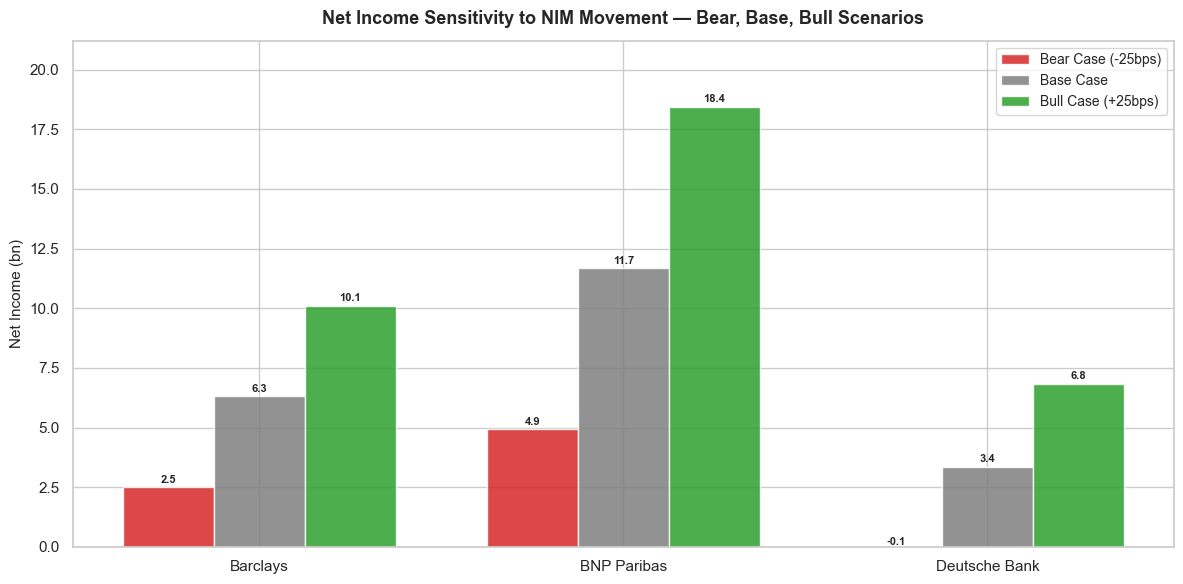

In [8]:
# Grouped bar chart — three banks, three scenarios per bank
# Shows absolute net income under each scenario side by side

x     = np.arange(len(banks))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, (scenario, nim_shift) in enumerate(scenarios.items()):
    income_values = [results[name][scenario]["Net Income (bn)"] for name in banks]
    bars = ax.bar(x + (i - 1) * width, income_values, width,
                  label=scenario,
                  color=scenario_colours[scenario],
                  alpha=0.85)
    
    # Add value labels on each bar
    for bar, val in zip(bars, income_values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.1,
                f"{val:.1f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_title("Net Income Sensitivity to NIM Movement — Bear, Base, Bull Scenarios",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Net Income (bn)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(banks, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, max([results[name]["Bull Case (+25bps)"]["Net Income (bn)"]
                    for name in banks]) * 1.15)

plt.tight_layout()
os.makedirs("../outputs", exist_ok=True)
plt.savefig("../outputs/sensitivity_net_income.png", dpi=150, bbox_inches="tight")
plt.show()

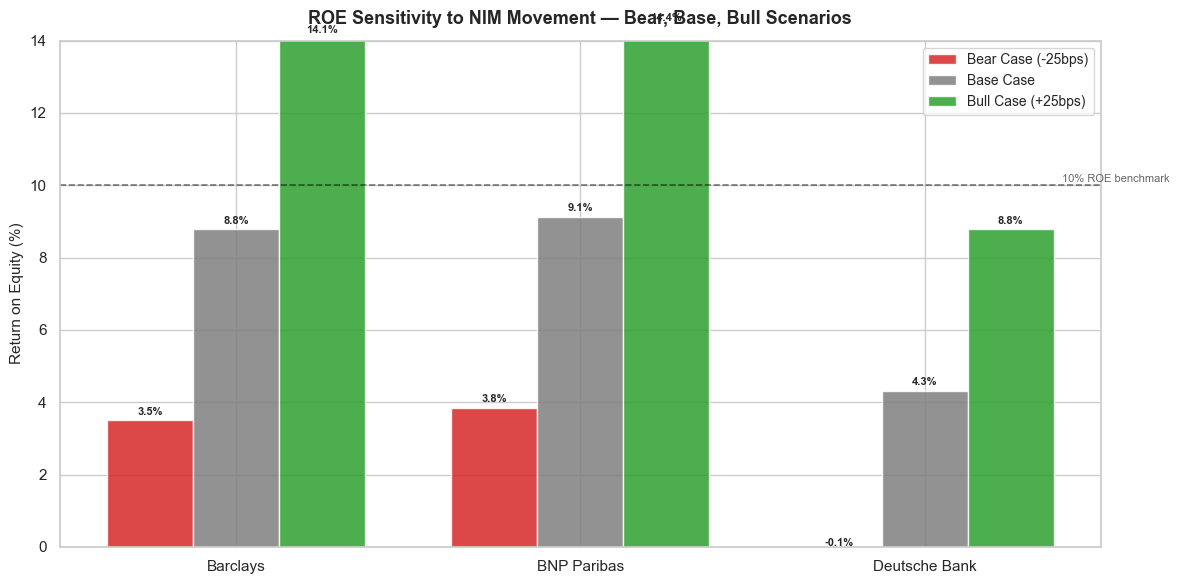

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

for i, (scenario, nim_shift) in enumerate(scenarios.items()):
    roe_values = [results[name][scenario]["ROE (%)"] for name in banks]
    bars = ax.bar(x + (i - 1) * width, roe_values, width,
                  label=scenario,
                  color=scenario_colours[scenario],
                  alpha=0.85)
    
    for bar, val in zip(bars, roe_values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.1,
                f"{val:.1f}%",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

# 10% benchmark line
ax.axhline(y=10, color="black", linestyle="--", linewidth=1.2, alpha=0.5)
ax.text(2.4, 10.1, "10% ROE benchmark", fontsize=8, color="black", alpha=0.6)

ax.set_title("ROE Sensitivity to NIM Movement — Bear, Base, Bull Scenarios",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Return on Equity (%)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(banks, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 14)

plt.tight_layout()
plt.savefig("../outputs/sensitivity_roe.png", dpi=150, bbox_inches="tight")
plt.show()

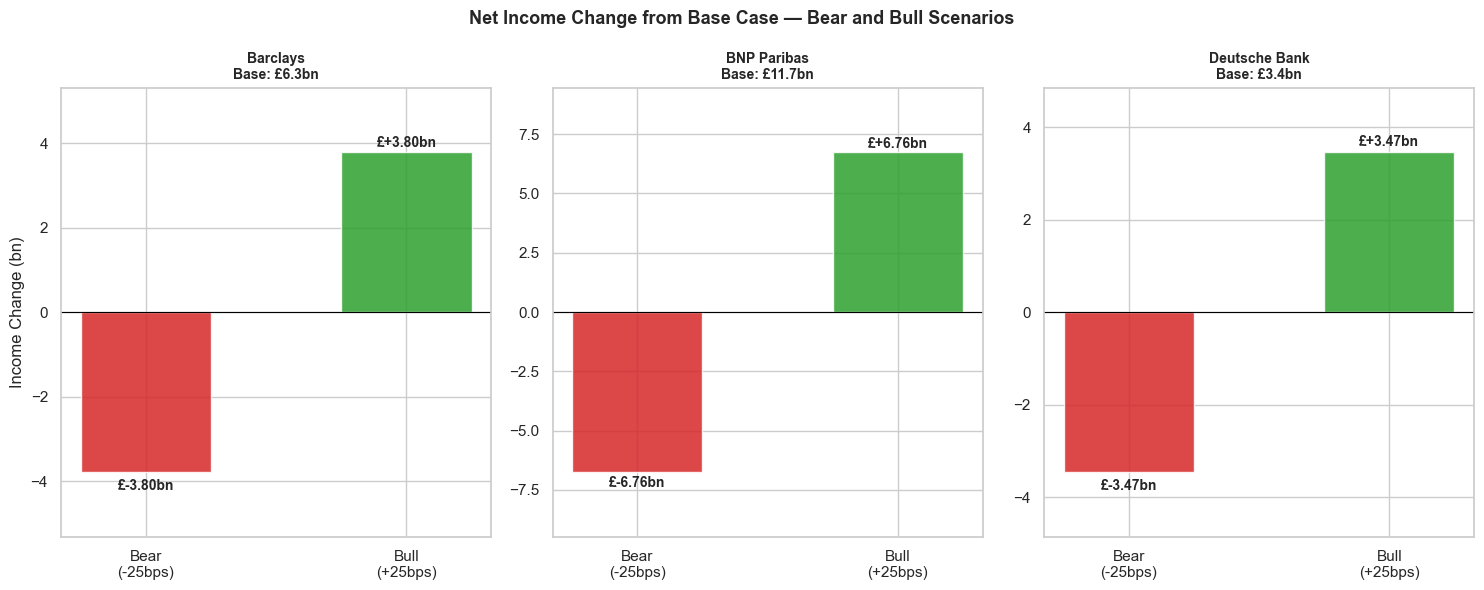

In [10]:
# A waterfall style chart showing income change from base case
# in both directions for each bank
# This makes the asymmetry of risk and reward visible

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle("Net Income Change from Base Case — Bear and Bull Scenarios",
             fontsize=13, fontweight="bold")

for i, name in enumerate(banks):
    ax = axes[i]
    
    bear_change = results[name]["Bear Case (-25bps)"]["Income Change (bn)"]
    bull_change = results[name]["Bull Case (+25bps)"]["Income Change (bn)"]
    base_income = results[name]["Base Case"]["Net Income (bn)"]
    
    bars = ax.bar(
        ["Bear\n(-25bps)", "Bull\n(+25bps)"],
        [bear_change, bull_change],
        color=[scenario_colours["Bear Case (-25bps)"],
               scenario_colours["Bull Case (+25bps)"]],
        alpha=0.85,
        width=0.5
    )
    
    for bar, val in zip(bars, [bear_change, bull_change]):
        offset = -0.15 if val < 0 else 0.05
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + offset,
                f"£{val:+.2f}bn",
                ha="center", va="top" if val < 0 else "bottom",
                fontsize=10, fontweight="bold")
    
    ax.axhline(y=0, color="black", linewidth=0.8)
    ax.set_title(f"{name}\nBase: £{base_income:.1f}bn", fontsize=10, fontweight="bold")
    ax.set_ylabel("Income Change (bn)" if i == 0 else "")
    ax.set_ylim(min(bear_change * 1.4, -1), max(bull_change * 1.4, 1))

plt.tight_layout()
plt.savefig("../outputs/sensitivity_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

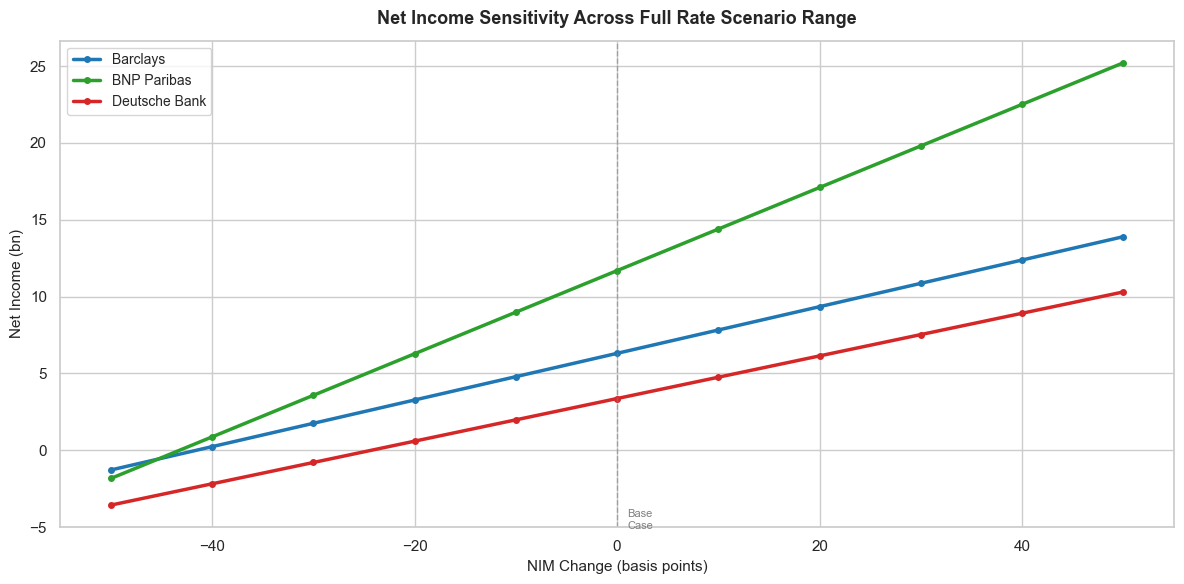

In [11]:
# Rather than just three scenarios we now model a full range
# from -50bps to +50bps in 10bps increments
# This gives a continuous picture of earnings sensitivity

nim_shifts = np.arange(-0.50, 0.51, 0.10)   # -50bps to +50bps in 10bps steps

fig, ax = plt.subplots(figsize=(12, 6))

for name in banks:
    d = base_data[name]
    implied_equity_bn = d["net_income_bn"] / (d["roe_pct"] / 100)
    
    income_under_shifts = []
    
    for shift in nim_shifts:
        income_impact   = d["total_assets_bn"] * (shift / 100)
        new_net_income  = d["net_income_bn"] + income_impact
        income_under_shifts.append(new_net_income)
    
    ax.plot(nim_shifts * 100,   # convert back to basis points for x axis
            income_under_shifts,
            color=bank_colours[name],
            linewidth=2.5,
            marker="o",
            markersize=4,
            label=name)

# Mark the base case at 0bps
ax.axvline(x=0, color="grey", linestyle="--", linewidth=1, alpha=0.6)
ax.text(1, ax.get_ylim()[0] * 1.02, "Base\nCase", fontsize=8, color="grey")

ax.set_title("Net Income Sensitivity Across Full Rate Scenario Range",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("NIM Change (basis points)", fontsize=11)
ax.set_ylabel("Net Income (bn)", fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/sensitivity_full_range.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
print("""
SENSITIVITY ANALYSIS — KEY FINDINGS
============================================================

MODEL ASSUMPTIONS
We model the impact of NIM shifts on net income using the formula:
Income Impact = Total Assets × NIM Change
This assumes the full asset base is equally rate-sensitive.
In practice banks have a mix of fixed and floating rate assets
so the true sensitivity is somewhat lower — our model represents
an upper bound on rate sensitivity.

BARCLAYS — MODERATE RATE SENSITIVITY
Barclays has a large interest-rate sensitive balance sheet.
A 25bps NIM compression in the bear case would materially
reduce net income, while the bull case shows meaningful upside.
Given Barclays already demonstrated 19.9% income growth in 2024,
it has shown it can grow revenue — the question is whether NIM
holds up as the Bank of England continues its cutting cycle.

BNP PARIBAS — HIGHEST ABSOLUTE SENSITIVITY
BNP has the largest balance sheet of the three and therefore
shows the highest absolute income change under each scenario.
However its high cost base means any NIM compression hits
profitability particularly hard since it has less operational
buffer than Barclays or Deutsche Bank.

DEUTSCHE BANK — MOST VULNERABLE IN BEAR CASE
Deutsche Bank's already weak ROE of 4.3% means any further
NIM compression in the bear case pushes it dangerously close
to negligible returns for shareholders. This is the key risk.
In the bull case its improving cost structure means it has
the most ROE recovery potential — but only if rates cooperate.
The bear case reinforces the value trap concern identified
in Notebook 3.

OVERALL CONCLUSION
All three banks face NIM headwinds as the ECB cutting cycle
continues into 2025. Barclays is best positioned given its
revenue growth momentum and relatively lean cost base.
BNP faces the most pressure from its high costs meeting
falling NIM. Deutsche Bank remains the highest risk highest
reward scenario — operational improvement is real but
earnings remain highly rate dependent.
""")




SENSITIVITY ANALYSIS — KEY FINDINGS

MODEL ASSUMPTIONS
We model the impact of NIM shifts on net income using the formula:
Income Impact = Total Assets × NIM Change
This assumes the full asset base is equally rate-sensitive.
In practice banks have a mix of fixed and floating rate assets
so the true sensitivity is somewhat lower — our model represents
an upper bound on rate sensitivity.

BARCLAYS — MODERATE RATE SENSITIVITY
Barclays has a large interest-rate sensitive balance sheet.
A 25bps NIM compression in the bear case would materially
reduce net income, while the bull case shows meaningful upside.
Given Barclays already demonstrated 19.9% income growth in 2024,
it has shown it can grow revenue — the question is whether NIM
holds up as the Bank of England continues its cutting cycle.

BNP PARIBAS — HIGHEST ABSOLUTE SENSITIVITY
BNP has the largest balance sheet of the three and therefore
shows the highest absolute income change under each scenario.
However its high cost base means an